In [24]:
#imports
import pandas as pd
import os
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

Candidates:

'Cotrim_Figueiredo'
'Gouveia_Melo'
'Filipe'
'Marques_Mendes'
'Martins'
'Ventura'
'Pinto'
'Seguro'

In [25]:
# Select candidates 

person1 = 'Martins'
person2 = 'Gouveia_Melo'

## Load data

In [26]:
# ── Visual ────────────────────────────────────────────────────────────────────
pklfiles_visual = []
for file in os.listdir('Project_Features'):
    if file.endswith('visual.pkl') and person1 in file and person2 in file:
        pklfiles_visual.append(file)

visual_dfs = []
for video in pklfiles_visual:
    print(f"Loading visual: {video}")
    df = pd.read_pickle(os.path.join('Project_Features', video))
    visual_dfs.append(df)

df_visual = pd.concat(visual_dfs, ignore_index=True)
df_visual['video'] = df_visual['Frame'].str.extract(r'Frames/([^/]+)/')
df_visual['frame_number'] = df_visual['Frame'].str.extract(r'frame_(\d+)\.jpg').astype(int)
df_visual = df_visual.sort_values(by=['video', 'frame_number']).reset_index(drop=True)

# ── Audio ─────────────────────────────────────────────────────────────────────
pklfiles_audio = []
for file in os.listdir('Project_Features'):
    if file.endswith('audio.pkl') and person1 in file and person2 in file:
        pklfiles_audio.append(file)

audio_dfs = []
for video in pklfiles_audio:
    print(f"Loading audio: {video}")
    df = pd.read_pickle(os.path.join('Project_Features', video))
    df['video'] = video.replace('_audio.pkl', '')
    audio_dfs.append(df)

df_audio = pd.concat(audio_dfs, ignore_index=True)
df_audio = df_audio.sort_values(by=['video', 'time stamp']).reset_index(drop=True)

def parse_embedding(x):
    if isinstance(x, np.ndarray):
        return x
    return np.fromstring(str(x).strip('[]'), sep=' ')

df_audio['speak_embeddings'] = df_audio['speak_embeddings'].apply(parse_embedding)

Loading visual: Martins_vs_Gouveia_Melo_November_23_visual.pkl
Loading audio: Martins_vs_Gouveia_Melo_November_23_audio.pkl


## Gap verification

In [27]:
# Check the time coverage of audio segments
df_audio['time_end'] = df_audio['time stamp'] + df_audio['duration']

# Look at gaps between consecutive segments
df_audio_sorted = df_audio.sort_values('time stamp').reset_index(drop=True)
df_audio_sorted['gap'] = df_audio_sorted['time stamp'] - df_audio_sorted['time_end'].shift(1)

print(df_audio_sorted['gap'].describe())
print(f"\nFrames with no covering audio segment (gaps > 0): {(df_audio_sorted['gap'] > 0).sum()}")

count    98.000000
mean      3.093796
std       5.459819
min      -1.401000
25%       0.274250
50%       0.742500
75%       4.083500
max      35.336000
Name: gap, dtype: float64

Frames with no covering audio segment (gaps > 0): 85


This means a significant number of frames will have no matching audio segment. So we have two options for how to handle unmatched frames:

Option A — Drop them. Only keep frames that fall inside an audio segment. Cleaner data but we lose information, especially during silences between turns.

Option B — Keep them with NaN. Keep all frames and just leave audio features as NaN for unmatched ones. More complete picture but needs careful handling in the correlation analysis.

## Time alignement

In [28]:
# ── Time alignment ────────────────────────────────────────────────────────────
# frame_number = second at which the frame was captured (1 fps)
# Each audio segment covers [time stamp, time stamp + duration)
# For each frame, find the audio segment active at that second (Option A: drop unmatched frames)

matched_rows = []

for _, frame_row in df_visual.iterrows():
    t = frame_row['frame_number']
    
    # Find audio segment where t falls inside [time stamp, time_end)
    match = df_audio[(df_audio['time stamp'] <= t) & (df_audio['time_end'] > t)]
    
    if len(match) == 1: # len = 0 -> frame in gap; len > 1 -> overlapping segments, both cases we drop the frame
        combined = {**frame_row.to_dict(), **match.iloc[0].to_dict()} # Merge the two rows into one dictionary
        matched_rows.append(combined)

df_merged = pd.DataFrame(matched_rows).reset_index(drop=True)

print(f"Visual frames total:        {len(df_visual)}")
print(f"Frames matched to audio:    {len(df_merged)}")
print(f"Frames dropped (no match):  {len(df_visual) - len(df_merged)}")

Visual frames total:        2048
Frames matched to audio:    1729
Frames dropped (no match):  319


## Emotion/Audio Analysis

### Maping people to audio

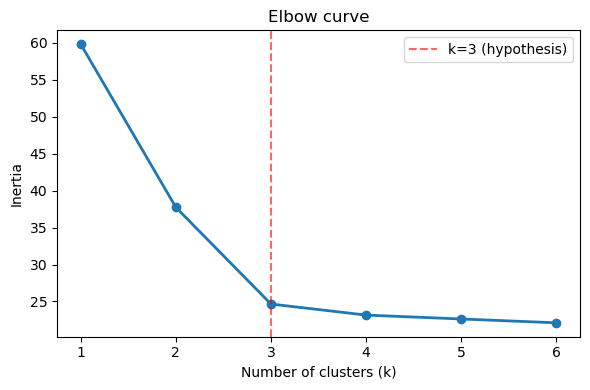

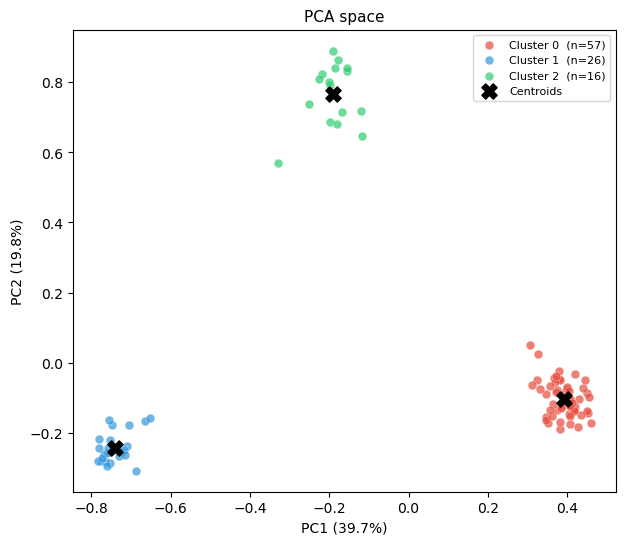

Silhouette Score for KMeans (k=3): 0.456


In [29]:
E = np.stack(df_audio['speak_embeddings'].values) 


pca = PCA(n_components=2, random_state=42) # Fit PCA on the original high-dimensional embeddings
E_2d = pca.fit_transform(E)
var1 = pca.explained_variance_ratio_[0] * 100
var2 = pca.explained_variance_ratio_[1] * 100

#  ---------- Elbow method to find optimal k ----------
ks = range(1, 7)
inertias = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(E).inertia_ for k in ks]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(list(ks), inertias, marker='o', linewidth=2)
ax.axvline(x=3, color='red', linestyle='--', alpha=0.6, label='k=3 (hypothesis)')
ax.set_xlabel('Number of clusters (k)')
ax.set_ylabel('Inertia')
ax.set_title(f'Elbow curve')
ax.legend()
plt.tight_layout()
plt.show()

colors = ['#e74c3c', '#3498db', '#2ecc71']

# ---------- KMeans clustering with k=3 ----------
k = 3 
km = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = km.fit_predict(E)

df_audio['cluster'] = labels # Add cluster labels to df_audio 

# Visualize clusters in PCA space
plt.figure(figsize=(7, 6))
for i in range(k):
    mask = labels == i
    plt.scatter(E_2d[mask, 0], E_2d[mask, 1], c=colors[i],
                   label=f'Cluster {i}  (n={mask.sum()})',
                   alpha=0.7, s=40, edgecolors='white', linewidth=0.3)
    centroids_2d = pca.transform(km.cluster_centers_)
plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1], 
            c='black', marker='X', s=120, zorder=5, label='Centroids')
plt.title('PCA space', fontsize=11)
plt.xlabel(f'PC1 ({var1:.1f}%)')
plt.ylabel(f'PC2 ({var2:.1f}%)')
plt.legend(fontsize=8)

plt.show()

# ---------- add the cluster labels to df_merged ----------
df_merged = df_merged.merge(
    df_audio[['time stamp', 'cluster']],
    on='time stamp',
    how='left'
)

# ---------- Silhouette score for KMeans ----------
from sklearn.metrics import silhouette_score
sil_score = silhouette_score(E, labels)
print(f"Silhouette Score for KMeans (k=3): {sil_score:.3f}")

Using only frames with exacly 1 face because thats the only way (that I know of) to be sure of who is talking

In [30]:
def count_faces(face_list):
    if isinstance(face_list, list):
        return sum(1 for face in face_list)
    
    return 0


df_merged['face_count'] = df_merged['Fer'].apply(count_faces)


# filter df_merged to have only frames with one face detected
df_one_face = df_merged[df_merged['face_count'] == 1]

In [31]:
print(f"Total frames in df_merged:        {len(df_merged)}")
print(f"Frames with exactly 1 face:       {len(df_one_face)}")
print(f"Cluster distribution in 1-face frames:")
print(df_one_face['cluster'].value_counts())

Total frames in df_merged:        1729
Frames with exactly 1 face:       817
Cluster distribution in 1-face frames:
cluster
1    393
0    322
2    102
Name: count, dtype: int64


In [32]:
# Extract emotion probabilities from the single face in each frame
def extract_emotions(face_list):
    face = face_list[0]  # we know there is exactly 1 face
    probs = face['probabilities']  # dictionary with 8 emotion keys
    result = {'top_emotion': face['top_emotion']}
    for emotion, prob in probs.items():
        result[f'prob_{emotion}'] = prob
    return pd.Series(result)

emotion_cols = df_one_face['Fer'].apply(extract_emotions)
df_one_face = pd.concat([df_one_face, emotion_cols], axis=1)

#print(df_one_face[['top_emotion'] + [c for c in df_one_face.columns if c.startswith('prob_')]].head())

### global correlation - emotion prob and voice features

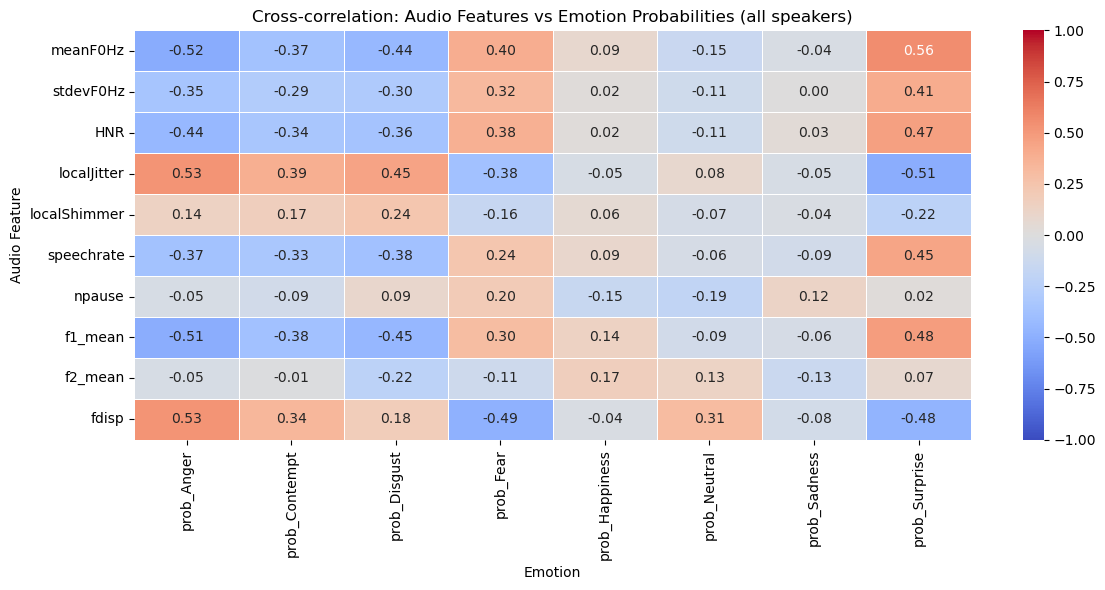

In [33]:
emotion_cols = [c for c in df_one_face.columns if c.startswith('prob_')]

NON_REDUNDANT = [
    'meanF0Hz', 'stdevF0Hz', 'HNR', 'localJitter', 'localShimmer',
    'speechrate', 'npause', 'f1_mean', 'f2_mean', 'fdisp'
] # based on EDA from Dinis


# correlation matrix for the non-redundant features + emotion probabilities
features_to_corr = NON_REDUNDANT + emotion_cols
corr_matrix = df_one_face[features_to_corr].corr(method='spearman')

cross_corr = corr_matrix.loc[NON_REDUNDANT, emotion_cols]

plt.figure(figsize=(12, 6))
sns.heatmap(cross_corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Cross-correlation: Audio Features vs Emotion Probabilities (all speakers)')
plt.xlabel('Emotion')
plt.ylabel('Audio Feature')
plt.tight_layout()
plt.show()


### Per cluster analysis

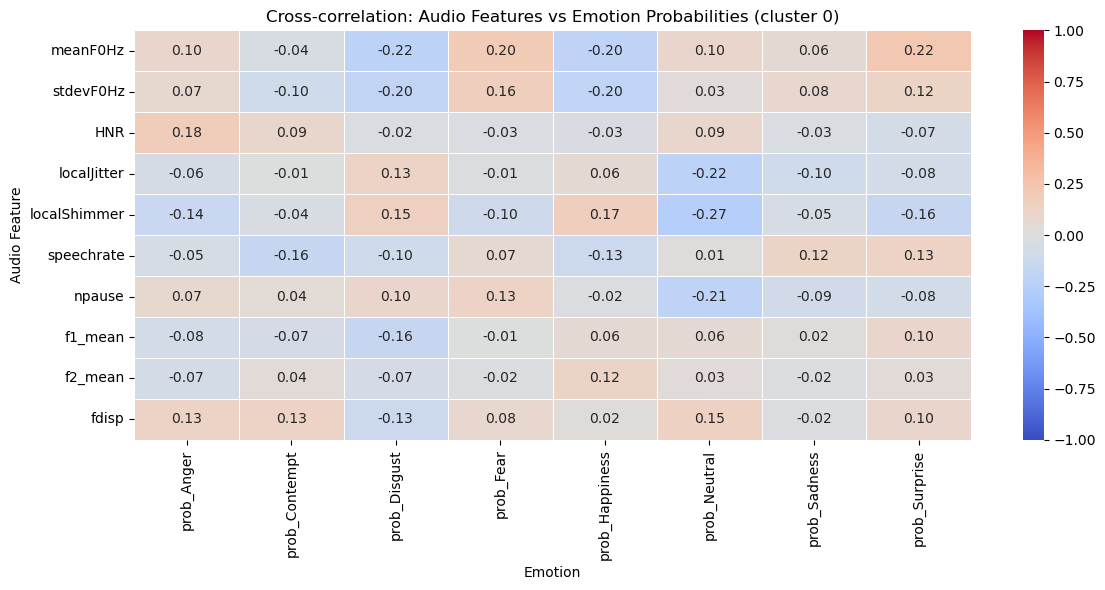

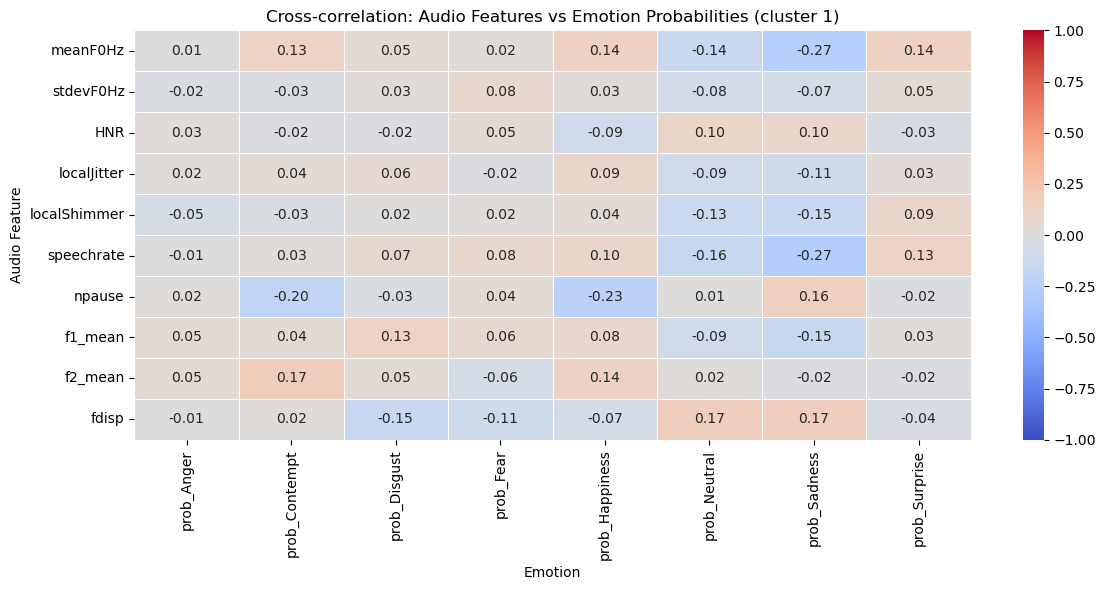

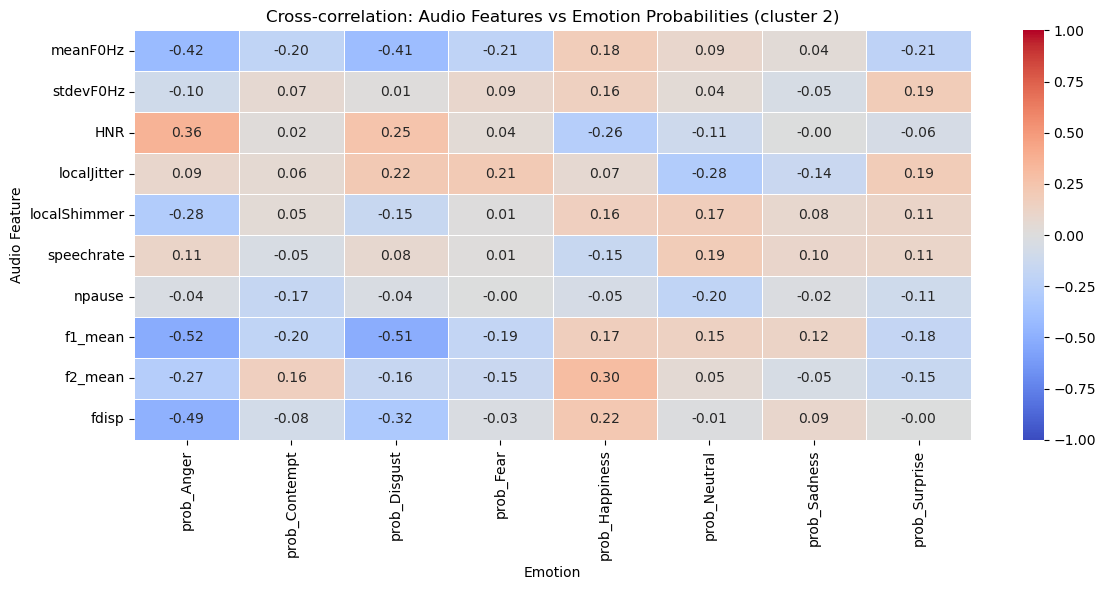

In [34]:
for cluster_id in sorted(df_one_face['cluster'].unique()):
    df_cluster = df_one_face[df_one_face['cluster'] == cluster_id]
    corr_matrix = df_cluster[features_to_corr].corr(method='spearman')
    cross_corr = corr_matrix.loc[NON_REDUNDANT, emotion_cols]

    plt.figure(figsize=(12, 6))
    sns.heatmap(cross_corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
    plt.title(f'Cross-correlation: Audio Features vs Emotion Probabilities (cluster {cluster_id})')
    plt.xlabel('Emotion')
    plt.ylabel('Audio Feature')
    plt.tight_layout()
    plt.show()
    

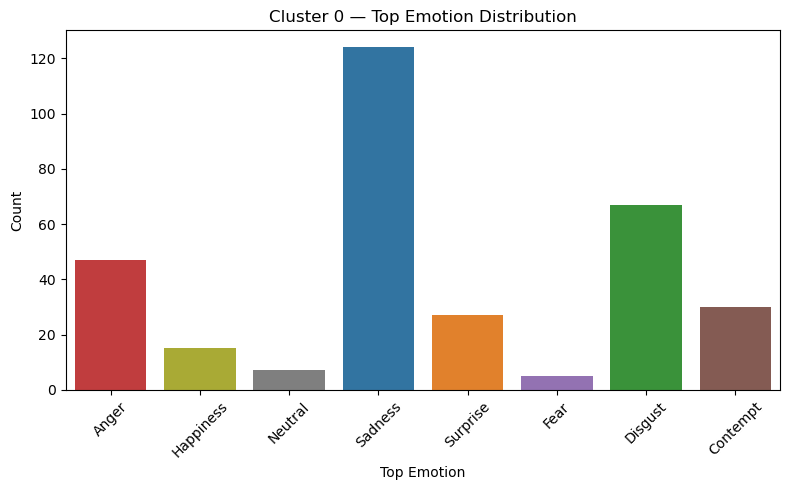

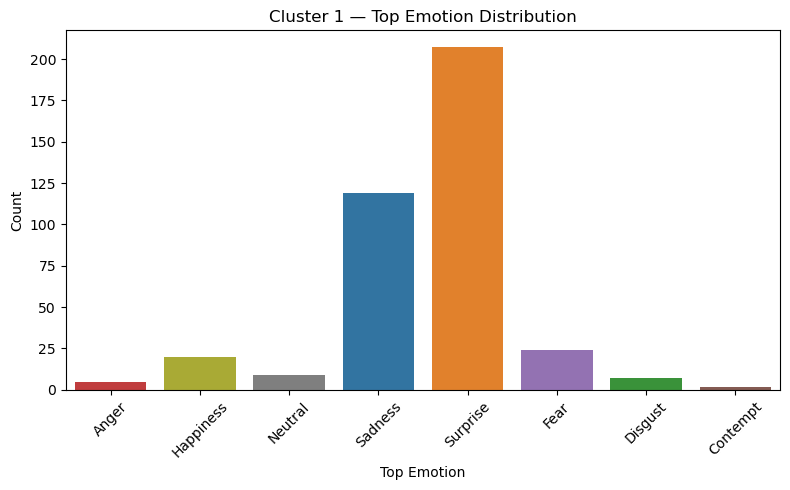

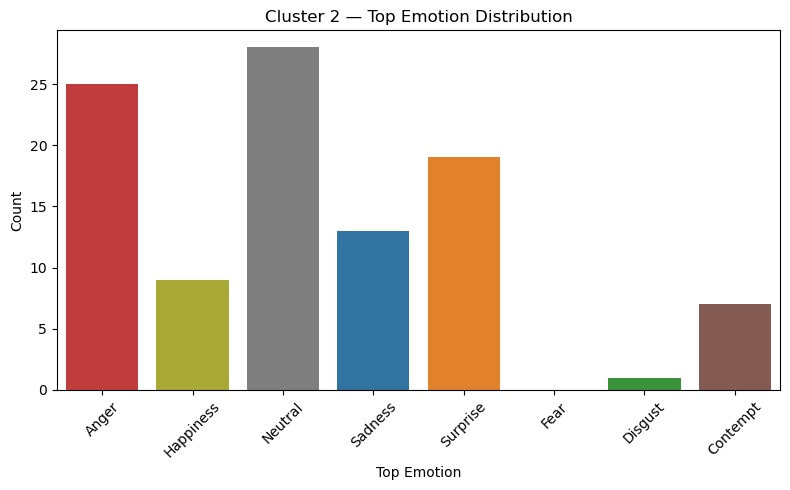

In [35]:
emotion_colors = {
    'Anger': 'tab:red',
    'Happiness': 'tab:olive',
    'Neutral': 'tab:gray',
    'Sadness': 'tab:blue',
    'Surprise': 'tab:orange',
    'Fear': 'tab:purple',
    'Disgust': 'tab:green',
    'Contempt': 'tab:brown',
}

for cluster_id in sorted(df_one_face['cluster'].unique()):
    df_cluster = df_one_face[df_one_face['cluster'] == cluster_id]
    #print(f"\nCluster {cluster_id} — top_emotion distribution:")
    #print(df_cluster['top_emotion'].value_counts())

    plt.figure(figsize=(8, 5))
    sns.countplot(data=df_cluster, x='top_emotion', order=emotion_colors.keys(), palette=emotion_colors, hue = 'top_emotion',
        legend=False)
    plt.title(f'Cluster {cluster_id} — Top Emotion Distribution')
    plt.xlabel('Top Emotion')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()


CONCLUSION: there is no meaningful within-speaker audio-emotion correlation in this debate

The bigger picture issue — The near-zero within-cluster correlations are consistent across all clusters. This strongly suggests that Pearson/Spearman (we tried both) correlation between instantaneous audio features and facial emotions is simply not a strong signal in this data

Simpson's Paradox: a statistical phenomenon where a trend or association observed in separate groups of data disappears or completely reverses when those groups are combined.

The temporal mismatch between audio segments (variable length, up to 40s) and visual frames (1 second snapshots) means we're comparing very different time scales
Facial emotion detection in debate videos may not be reliable enough

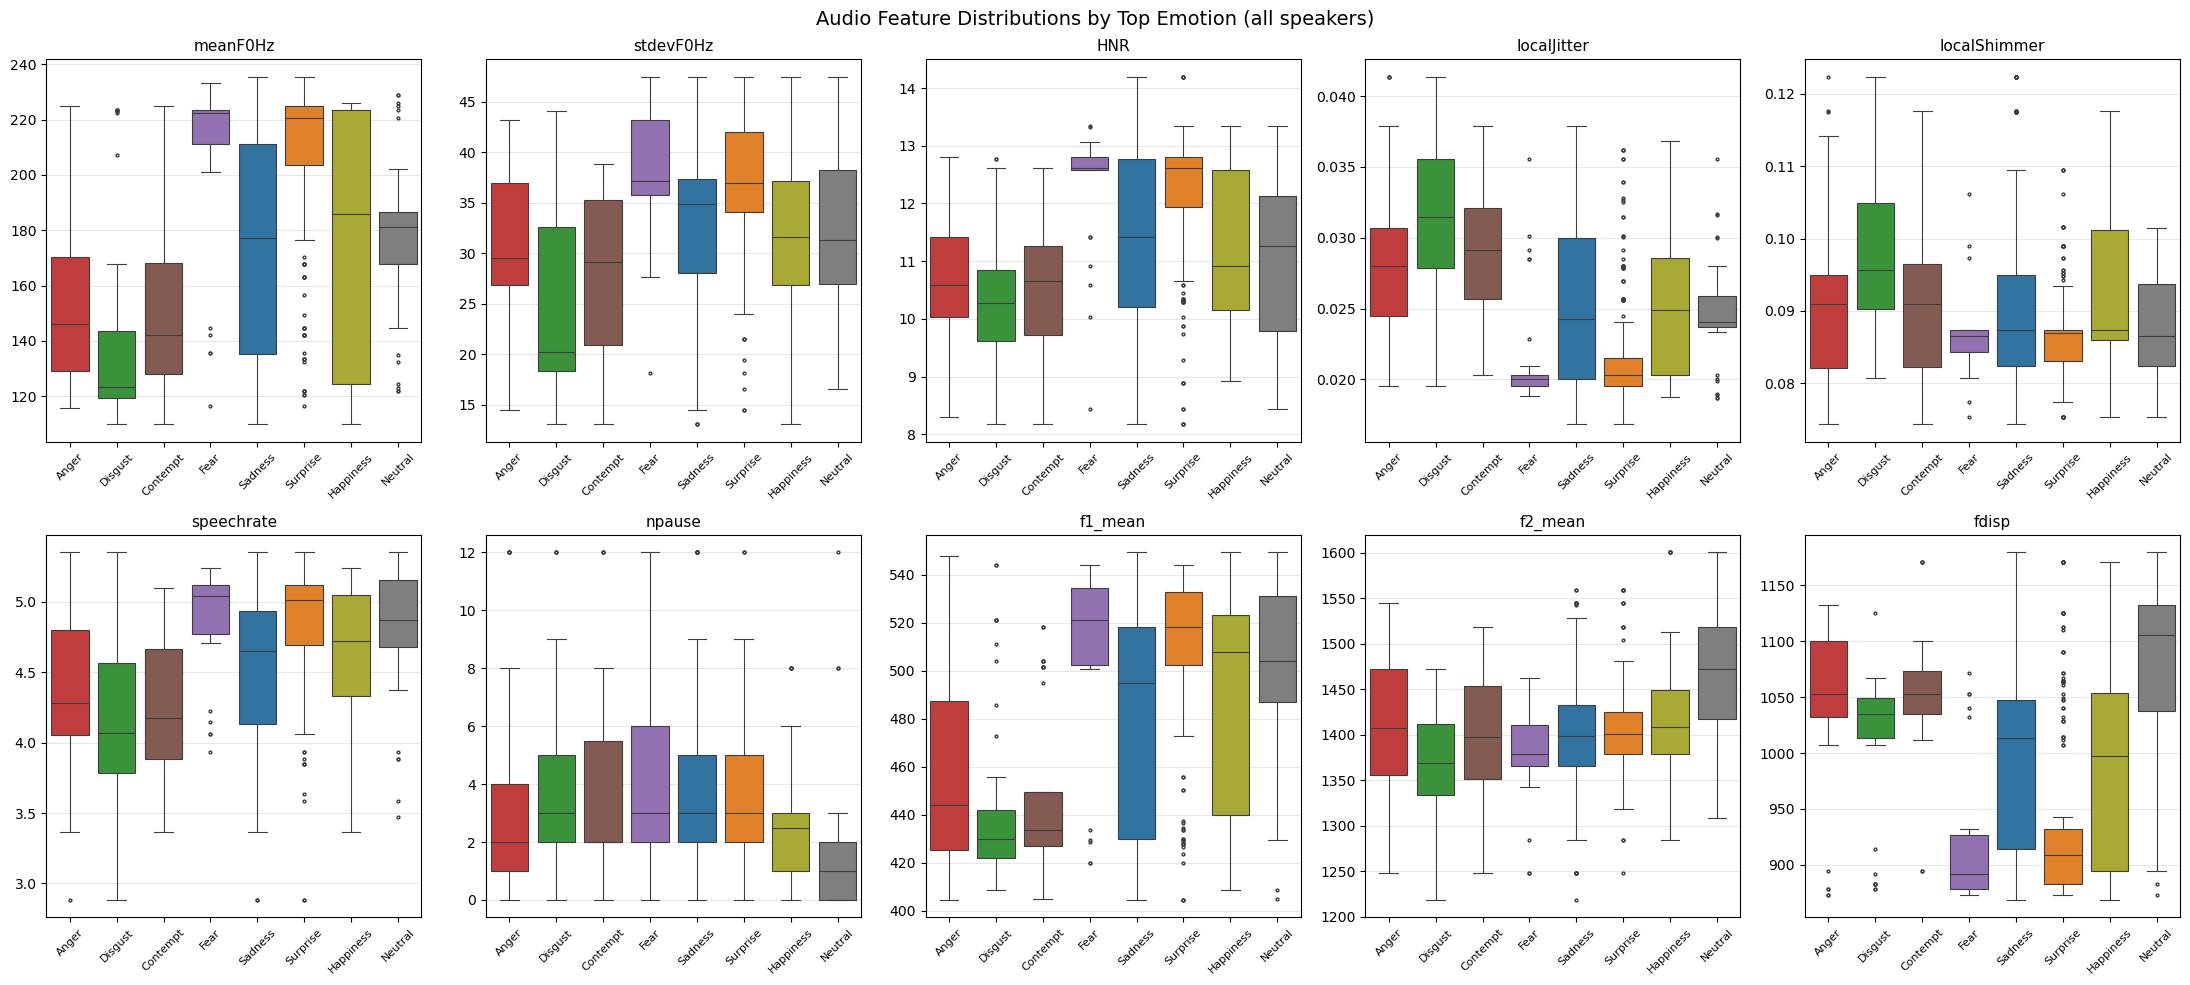

In [36]:
# ── Box plots of audio features grouped by top_emotion ────────────────────────

# We need df_one_face which has both top_emotion and audio features
# (it was built from df_merged so audio features are already there)

emotion_order = ['Anger', 'Disgust', 'Contempt', 'Fear', 'Sadness', 'Surprise', 'Happiness', 'Neutral']
emotion_palette = {
    'Anger': 'tab:red',
    'Happiness': 'tab:olive',
    'Neutral': 'tab:gray',
    'Sadness': 'tab:blue',
    'Surprise': 'tab:orange',
    'Fear': 'tab:purple',
    'Disgust': 'tab:green',
    'Contempt': 'tab:brown',
}

fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

for i, feature in enumerate(NON_REDUNDANT):
    ax = axes[i]
    sns.boxplot(
        data=df_one_face,
        x='top_emotion',
        y=feature,
        order=emotion_order,
        palette=emotion_palette,
        ax=ax,
        linewidth=0.8,
        fliersize=2, 
        hue = 'top_emotion',
        legend=False
    )
    ax.set_title(feature, fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.grid(axis='y', alpha=0.3)

# hide the last empty subplot (10 features, 10 subplots — actually fits perfectly)
fig.suptitle('Audio Feature Distributions by Top Emotion (all speakers)', fontsize=14)
plt.tight_layout()
plt.show()



In [37]:
# Mean audio features per dominant emotion
summary = df_one_face.groupby('top_emotion')[NON_REDUNDANT].mean().round(2)
print(summary)

             meanF0Hz  stdevF0Hz    HNR  localJitter  localShimmer  \
top_emotion                                                          
Anger          153.34      30.21  10.73         0.03          0.09   
Contempt       148.60      28.04  10.52         0.03          0.09   
Disgust        135.81      25.24  10.19         0.03          0.10   
Fear           206.21      37.51  12.31         0.02          0.09   
Happiness      178.84      30.97  11.23         0.03          0.09   
Neutral        178.76      32.44  11.14         0.02          0.09   
Sadness        174.63      32.72  11.31         0.03          0.09   
Surprise       207.39      37.01  12.19         0.02          0.09   

             speechrate  npause  f1_mean  f2_mean    fdisp  
top_emotion                                                 
Anger              4.42    3.23   457.12  1409.96  1054.62  
Contempt           4.22    3.62   447.17  1394.49  1054.41  
Disgust            4.07    3.91   438.97  1372.10  1023

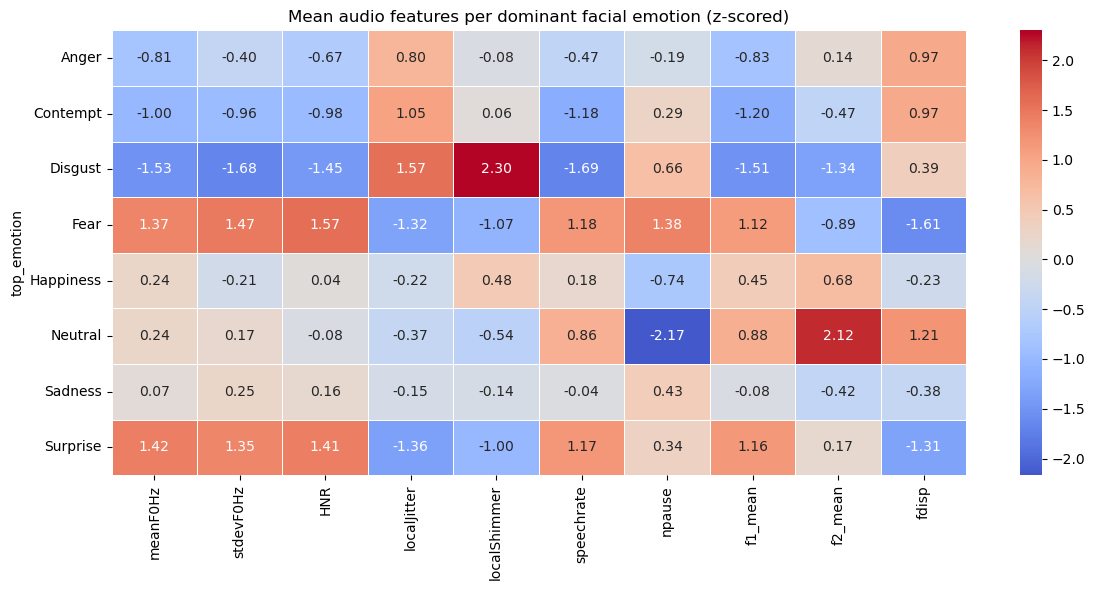

In [38]:
from scipy.stats import zscore

summary_z = df_one_face.groupby('top_emotion')[NON_REDUNDANT].mean()
summary_z = summary_z.apply(zscore)

plt.figure(figsize=(12, 6))
sns.heatmap(summary_z, annot=True, fmt='.2f', cmap='coolwarm', 
            linewidths=0.5, center=0)
plt.title('Mean audio features per dominant facial emotion (z-scored)')
plt.tight_layout()
plt.show()

meanF0Hz (pitch):

Disgust has the lowest pitch (135 Hz) — very low, flat voice
Fear and Surprise have the highest pitch (206-207 Hz) — elevated, tense voice
Clear pattern: negative heavy emotions → lower pitch, reactive emotions → higher pitch

localJitter:

Fear and Neutral and Surprise have lower jitter (0.02) — more stable voice
Anger, Contempt, Disgust have higher jitter (0.03) — more irregular voice
Makes sense: sustained negative emotions create voice tension/irregularity

speechrate:

Disgust slowest (4.07 syl/s) — deliberate, slow speech
Fear and Surprise fastest (4.89) — rapid, reactive speech
Contempt also slow (4.22) — deliberate dismissive speech

npause:

Neutral has fewest pauses (1.66) — fluent, composed speech
Disgust has most pauses (3.91) — halting, heavy speech

f1_mean:

Fear and Surprise highest (508-509 Hz) — open mouth, raised tongue
Disgust lowest (438 Hz) — closed, tense mouth position

## Emotion/Time Analysis

Total face detections: 3263
Frames covered: 2047


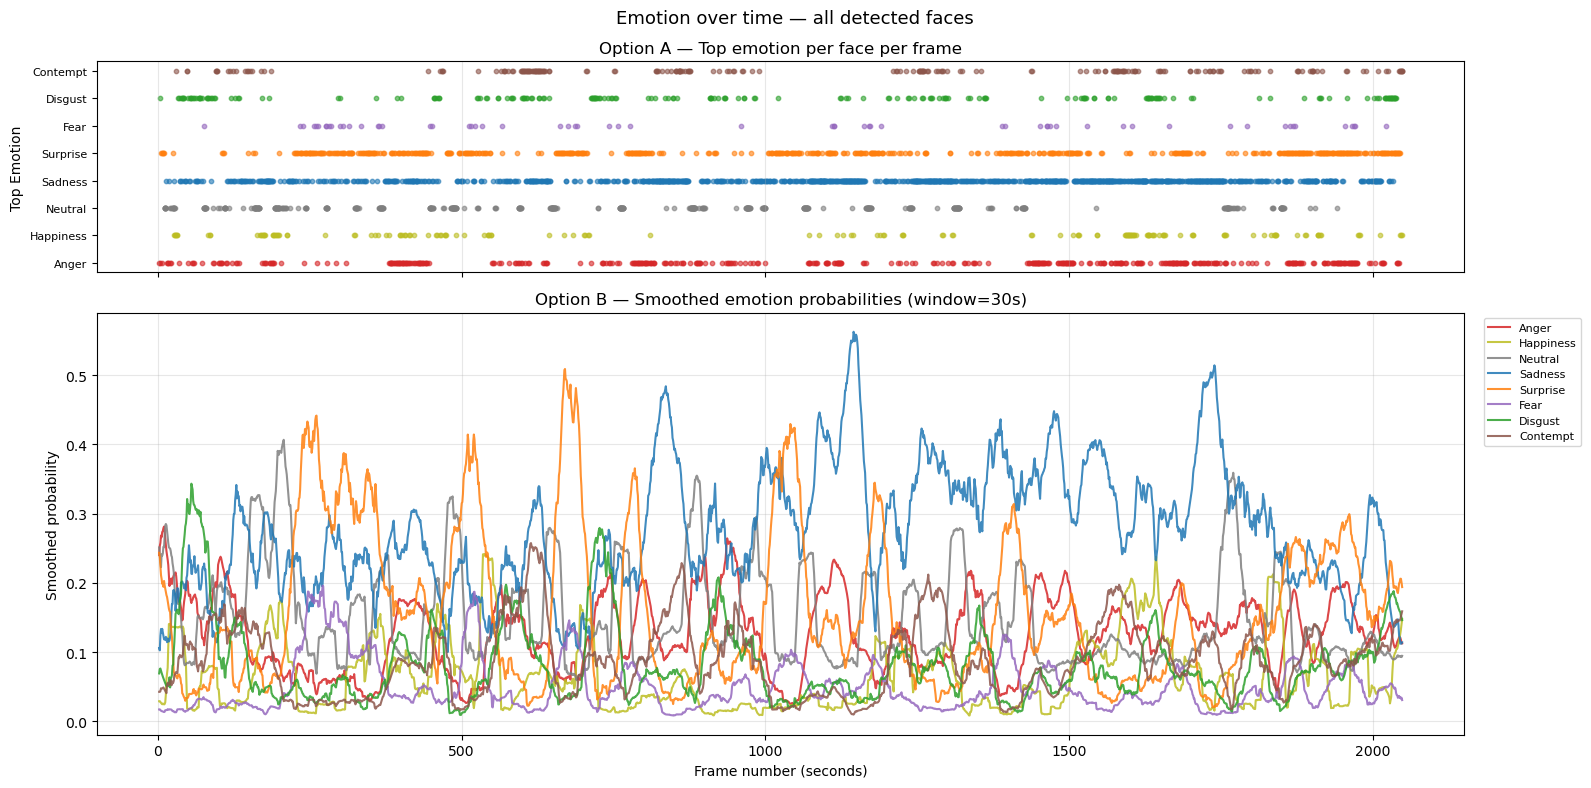

In [39]:
# ── Emotion over time ─────────────────────────────────────────────────────────

emotion_colors = {
    'Anger': 'tab:red',
    'Happiness': 'tab:olive',
    'Neutral': 'tab:gray',
    'Sadness': 'tab:blue',
    'Surprise': 'tab:orange',
    'Fear': 'tab:purple',
    'Disgust': 'tab:green',
    'Contempt': 'tab:brown',
}

WINDOW = 30  # rolling average window in frames (seconds)

# ── Explode df_visual so each detected face is its own row ───────────────────
face_rows = []
for _, frame_row in df_visual.iterrows():
    for face in frame_row['Fer']:
        if isinstance(face, dict):
            probs = face['probabilities']
            row = {'frame_number': frame_row['frame_number'],
                   'top_emotion': face['top_emotion']}
            for emotion, prob in probs.items():
                row[f'prob_{emotion}'] = prob
            face_rows.append(row)

df_faces_time = pd.DataFrame(face_rows).sort_values('frame_number').reset_index(drop=True)

print(f"Total face detections: {len(df_faces_time)}")
print(f"Frames covered: {df_faces_time['frame_number'].nunique()}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True,
                                gridspec_kw={'height_ratios': [1, 2]})
fig.suptitle('Emotion over time — all detected faces', fontsize=13)

# Option A: categorical scatter
emotion_categories = list(emotion_colors.keys())
y_positions = {e: i for i, e in enumerate(emotion_categories)}

for emotion, color in emotion_colors.items():
    mask = df_faces_time['top_emotion'] == emotion
    ax1.scatter(
        df_faces_time.loc[mask, 'frame_number'],
        [y_positions[emotion]] * mask.sum(),
        c=color, s=10, alpha=0.6, label=emotion
    )

ax1.set_yticks(range(len(emotion_categories)))
ax1.set_yticklabels(emotion_categories, fontsize=8)
ax1.set_ylabel('Top Emotion')
ax1.set_title('Option A — Top emotion per face per frame')
ax1.grid(axis='x', alpha=0.3)

# Option B: smoothed probability lines
prob_cols = [f'prob_{e}' for e in emotion_colors.keys()]
df_smoothed = df_faces_time.groupby('frame_number')[prob_cols].mean()

for emotion, color in emotion_colors.items():
    prob_col = f'prob_{emotion}'
    smoothed = df_smoothed[prob_col].rolling(
        window=WINDOW, center=True, min_periods=1
    ).mean()
    ax2.plot(smoothed.index, smoothed.values, color=color,
             label=emotion, linewidth=1.5, alpha=0.85)

ax2.set_xlabel('Frame number (seconds)')
ax2.set_ylabel('Smoothed probability')
ax2.set_title(f'Option B — Smoothed emotion probabilities (window={WINDOW}s)')
ax2.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Face detections with cluster label: 2769
Face detections dropped (no audio match): 494


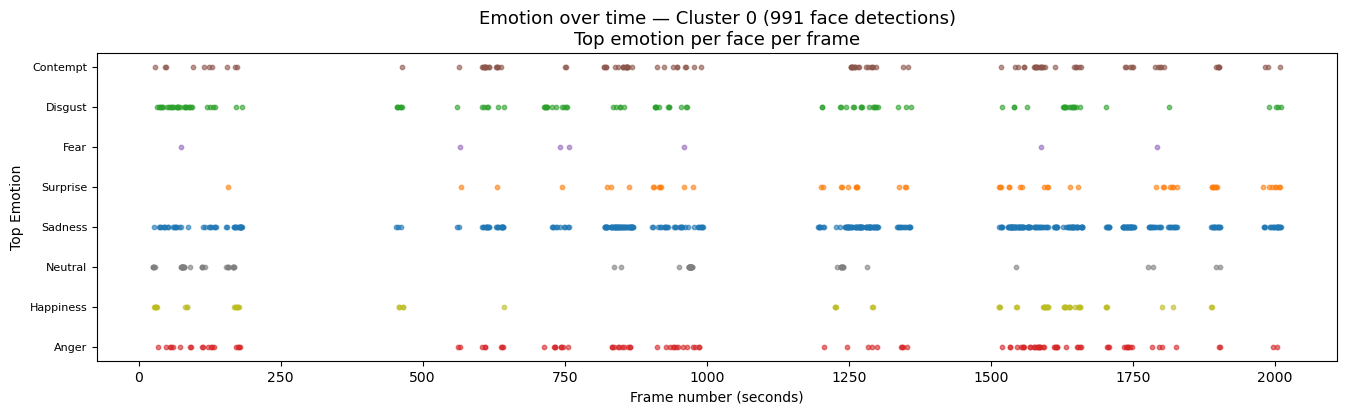

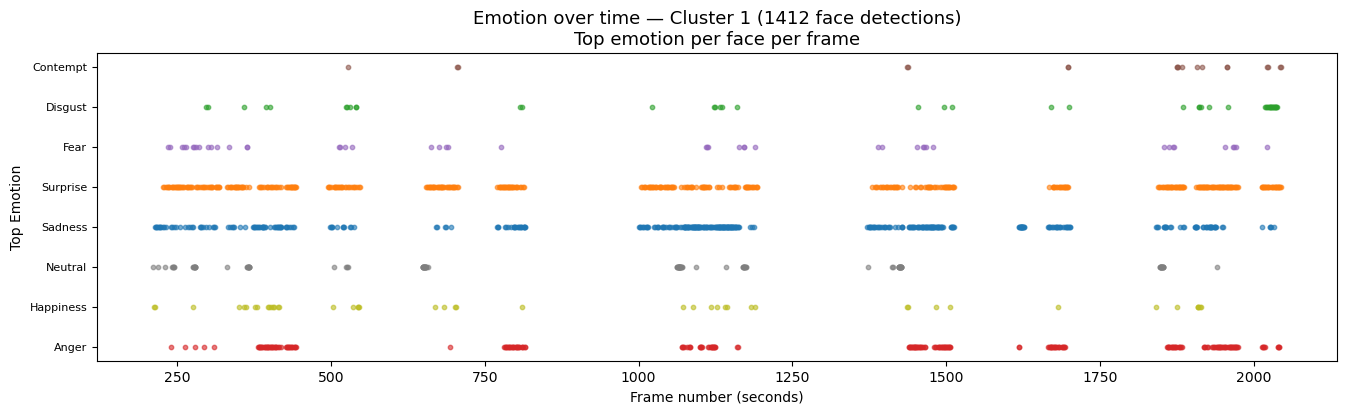

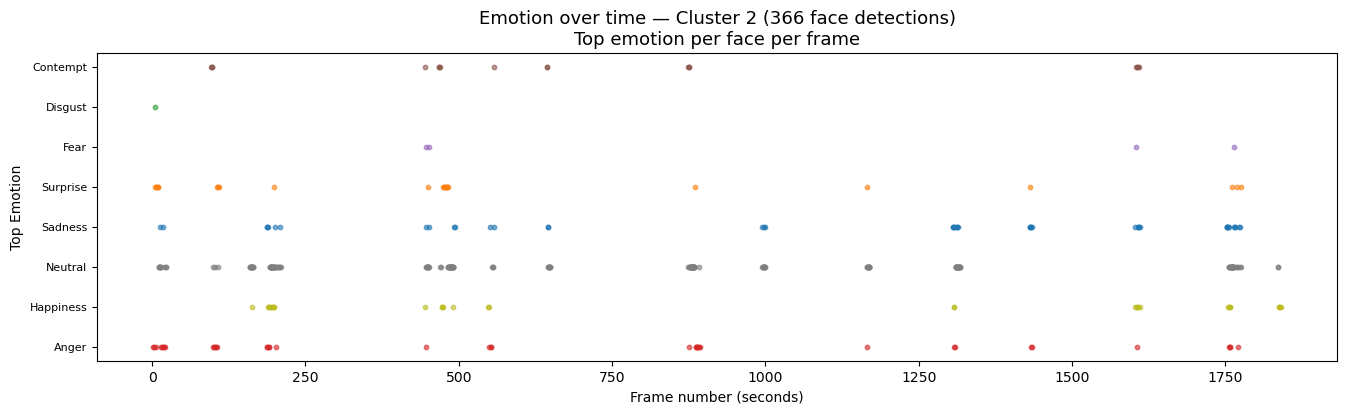

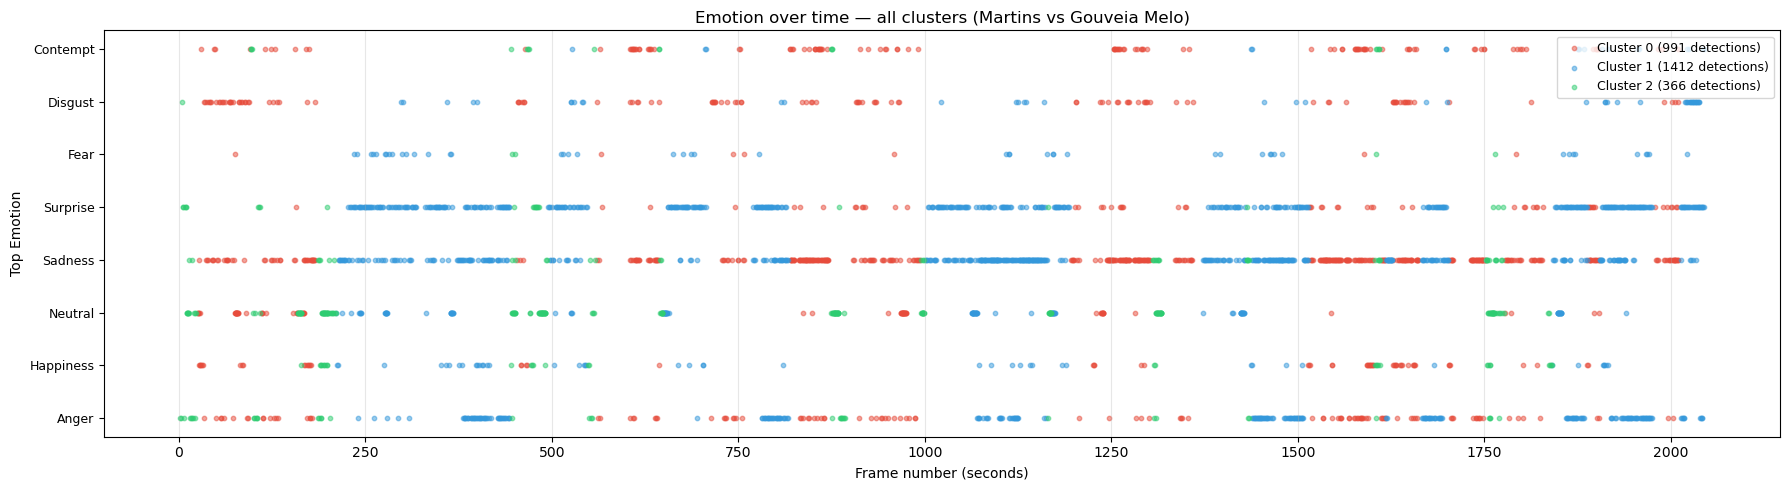

In [40]:
# ── Merge cluster labels into df_faces_time ───────────────────────────────────
df_faces_time = df_faces_time.merge(
    df_merged[['frame_number', 'cluster']].drop_duplicates('frame_number'),
    on='frame_number',
    how='left'
)

# Drop frames with no cluster label (no matching audio segment)
df_faces_clustered = df_faces_time.dropna(subset=['cluster']).copy()
df_faces_clustered['cluster'] = df_faces_clustered['cluster'].astype(int)

print(f"Face detections with cluster label: {len(df_faces_clustered)}")
print(f"Face detections dropped (no audio match): {len(df_faces_time) - len(df_faces_clustered)}")

# ── Plot per cluster ──────────────────────────────────────────────────────────
for cluster_id in sorted(df_faces_clustered['cluster'].unique()):
    df_cluster = df_faces_clustered[df_faces_clustered['cluster'] == cluster_id].sort_values('frame_number')
    
    fig, ax = plt.subplots(figsize=(16, 4))
    ax.set_title(f'Emotion over time — Cluster {cluster_id} ({len(df_cluster)} face detections)\nTop emotion per face per frame', fontsize=13)
    
    # Categorical scatter (Option A)
    emotion_categories = list(emotion_colors.keys())
    y_positions = {e: i for i, e in enumerate(emotion_categories)}
    
    for emotion, color in emotion_colors.items():
        mask = df_cluster['top_emotion'] == emotion
        ax.scatter(
            df_cluster.loc[mask, 'frame_number'],
            [y_positions[emotion]] * mask.sum(),
            c=color, s=10, alpha=0.6
        )
    
    # Set ticks and labels
    ax.set_yticks(range(len(emotion_categories)))
    ax.set_yticklabels(emotion_categories, fontsize=8)
    ax.set_ylabel('Top Emotion')
    
    # Add the x-label here since the bottom plot was removed
    ax.set_xlabel('Frame number (seconds)')

# ── All clusters in one plot, colored by cluster ──────────────────────────────

cluster_colors = {0: '#e74c3c', 1: '#3498db', 2: '#2ecc71'}

emotion_categories = list(emotion_colors.keys())
y_positions = {e: i for i, e in enumerate(emotion_categories)}

fig, ax = plt.subplots(figsize=(18, 5))

for cluster_id in sorted(df_faces_clustered['cluster'].unique()):
    df_cluster = df_faces_clustered[df_faces_clustered['cluster'] == cluster_id].sort_values('frame_number')
    color = cluster_colors[cluster_id]
    
    y_vals = df_cluster['top_emotion'].map(y_positions)
    ax.scatter(
        df_cluster['frame_number'],
        y_vals,
        c=color,
        s=10,
        alpha=0.5,
        label=f'Cluster {cluster_id} ({len(df_cluster)} detections)'
    )

ax.set_yticks(range(len(emotion_categories)))
ax.set_yticklabels(emotion_categories, fontsize=9)
ax.set_xlabel('Frame number (seconds)')
ax.set_ylabel('Top Emotion')
ax.set_title('Emotion over time — all clusters (Martins vs Gouveia Melo)')
ax.legend(fontsize=9, loc='upper right')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

The two candidates have very distinct and consistent emotional profiles throughout the entire debate. One is predominantly "Surprise" and the other predominantly "Sadness/Disgust". This is a strong finding — the emotion model seems to be picking up on stable facial expression styles rather than momentary emotions, which explains why we found no audio-emotion correlations earlier.

### Pose/Emotions Analysis

In [41]:
master_data = []
for index, row in df_visual.iterrows():
    frame_id = row['Frame']
    faces = row['Fer']
    poses = row['Poses'] # This contains the body bbox and the 17 keypoints
    frame_number = row['frame_number']
    
    if isinstance(faces, list) and len(faces) > 0 and len(faces)<=3:
        valid_faces = [f for f in faces if isinstance(f, dict) and 'bbox' in f]
        people_count = len(valid_faces)
        
        for i, face in enumerate(valid_faces):
            # 1. Face Coordinates
            f_box = face['bbox'] # [x1, y1, x2, y2]
            f_width = f_box[2] - f_box[0]
            f_height = f_box[3] - f_box[1]
            
            f_x_center = f_box[0] + (f_width / 2)
            f_y_center = f_box[1] + (f_height / 2) # Get Y center too!
            face_area = f_width * f_height
            
            top_emotion = face.get('top_emotion')
            probability = face['probabilities'].get(top_emotion) if top_emotion and 'probabilities' in face else None
            landmarks = face.get('landmarks')
            
            # 2. MATCH THE BODY TO THE FACE
            matched_body_bbox = None
            matched_pose_keypoints = None
            
            if isinstance(poses, list):
                for person_body in poses:
                    if isinstance(person_body, dict)and len(person_body) > 0:
                        b_box = person_body['bbox'] 
                        
                        # is the center of the face inside this body's bounding box?
                        #note that b_box[3] > bbox[1] because y axis goes down
                        if (b_box[0] <= f_x_center <= b_box[2]) and (b_box[1] <= f_y_center <= b_box[3]):
                            matched_body_bbox = b_box
                            matched_pose_keypoints = person_body.get('pose') # The 17x3 matrix
                            break 
            
            # 3. Append everything safely
            master_data.append({
                'frame': frame_id,
                'frame_number': frame_number,
                'people_count': people_count,
                'person_index': i,
                'face_X_center': f_x_center,
                'face_area': face_area,
                'face_bbox': f_box,
                'body_bbox': matched_body_bbox,
                'top_emotion': top_emotion,
                'landmarks': landmarks,
                'pose_keypoints': matched_pose_keypoints,
                **{f'prob_{e}': p for e, p in face['probabilities'].items()}})
            
    else:
        # Handle empty frames
        master_data.append({
            'frame': frame_id,
            'frame_number': frame_number,
            'people_count': 0,
            'person_index': None,
            'face_X_center': None,
            'face_area': None,
            'face_bbox': None,
            'body_bbox': None,
            'top_emotion': None,
            'landmarks': None,
            'pose_keypoints': None
        })
df_master = pd.DataFrame(master_data)
print(f"Important data (df shape): {df_master.shape}")
print(df_master['pose_keypoints'].isna().sum())
print(f"Total rows: {len(df_master)}")


Important data (df shape): (3261, 19)
30
Total rows: 3261


In [42]:
KEYPOINTS = {
    'nose': 0, 'left_eye': 1, 'right_eye': 2,
    'left_ear': 3, 'right_ear': 4,
    'left_shoulder': 5, 'right_shoulder': 6,
    'left_elbow': 7, 'right_elbow': 8,
    'left_wrist': 9, 'right_wrist': 10,
    'left_hip': 11, 'right_hip': 12
}

def extract_pose_features(keypoints):
    if keypoints is None:
        return pd.Series({
            'shoulder_slope': None,
            'body_openness': None,
            'head_tilt': None,
            'wrist_height': None,
            'torso_height': None
        })
    
    kp = np.array(keypoints)  # 17x3: [x, y, visibility]
    
    l_shoulder = kp[5]
    r_shoulder = kp[6]
    l_wrist    = kp[9]
    r_wrist    = kp[10]
    l_hip      = kp[11]
    r_hip      = kp[12]
    nose       = kp[0]
    
    # slope between shoulders (positive = left higher, negative = right higher)
    shoulder_slope = r_shoulder[1] - l_shoulder[1]
    
    # horizontal distance between shoulders (wider = more open posture)
    body_openness = abs(r_shoulder[0] - l_shoulder[0])
    
    # nose x relative to shoulder midpoint (head tilt left/right)
    shoulder_mid_x = (l_shoulder[0] + r_shoulder[0]) / 2
    head_tilt = nose[0] - shoulder_mid_x
    
    # average wrist y relative to shoulder y (negative = wrists raised)
    shoulder_mid_y = (l_shoulder[1] + r_shoulder[1]) / 2
    wrist_height = shoulder_mid_y - ((l_wrist[1] + r_wrist[1]) / 2)
    
    # torso height: distance between shoulder midpoint and hip midpoint
    hip_mid_y = (l_hip[1] + r_hip[1]) / 2
    torso_height = abs(hip_mid_y - shoulder_mid_y)
    
    return pd.Series({
        'shoulder_slope': shoulder_slope,
        'body_openness': body_openness,
        'head_tilt': head_tilt,
        'wrist_height': wrist_height,
        'torso_height': torso_height
    })

# Apply to df_master, skipping rows with no pose
df_master_valid = df_master[df_master['pose_keypoints'].notna()].copy()
pose_features = df_master_valid['pose_keypoints'].apply(extract_pose_features)
df_master_valid = pd.concat([df_master_valid, pose_features], axis=1)

print(f"Valid rows for pose-emotion correlation: {len(df_master_valid)}")
print(df_master_valid[['shoulder_slope', 'body_openness', 'head_tilt', 'wrist_height', 'torso_height']].describe().round(2))

Valid rows for pose-emotion correlation: 3231
       shoulder_slope  body_openness  head_tilt  wrist_height  torso_height
count         3231.00        3231.00    3231.00       3231.00       3231.00
mean            11.22         217.96      -0.54       -132.51        160.21
std             14.71          80.01      30.89         42.65         40.60
min            -29.73           0.74    -100.52       -208.74         32.26
25%              1.29         211.71     -20.54       -158.65        158.96
50%              7.06         242.36       0.03       -141.29        170.75
75%             18.23         261.23      22.86       -125.04        184.25
max             59.38         318.97      91.87         -6.31        212.21


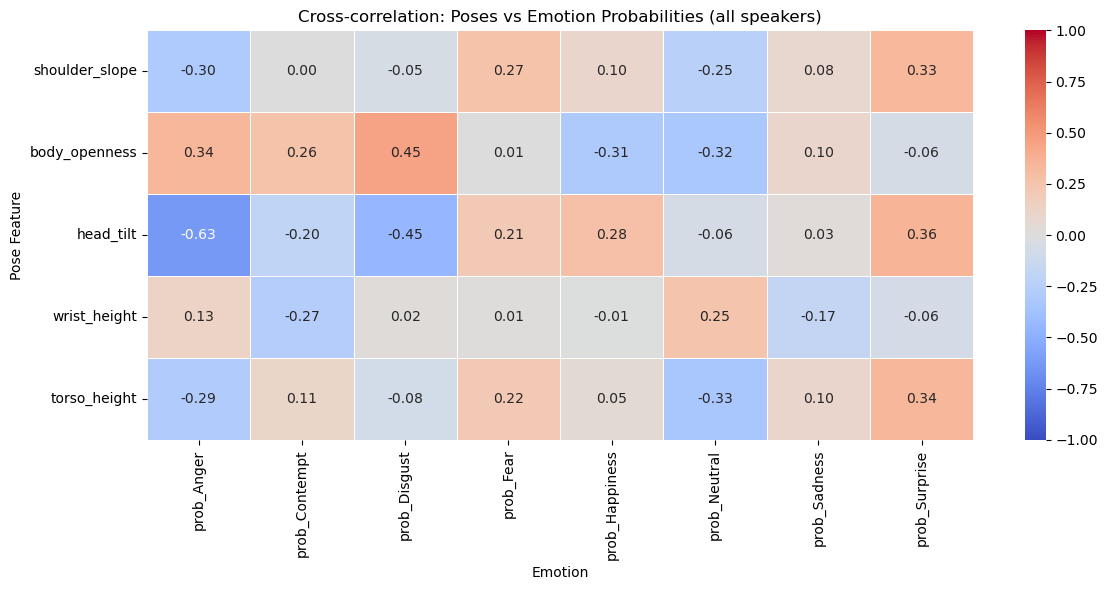

In [43]:
# correlation matrix for the non-redundant features + emotion probabilities
features_to_corr = ['shoulder_slope', 'body_openness', 'head_tilt', 'wrist_height', 'torso_height'] + emotion_cols
corr_matrix = df_master_valid[features_to_corr].corr(method='spearman')

cross_corr = corr_matrix.loc[['shoulder_slope', 'body_openness', 'head_tilt', 'wrist_height', 'torso_height'], emotion_cols]

plt.figure(figsize=(12, 6))
sns.heatmap(cross_corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Cross-correlation: Poses vs Emotion Probabilities (all speakers)')
plt.xlabel('Emotion')
plt.ylabel('Pose Feature')
plt.tight_layout()
plt.show()


body_openness — shoulder width:

- Positive with Anger (0.34) and Disgust (0.45) — wider stance associated with more negative emotions
- Negative with Neutral (-0.32) and Happiness (-0.31) — more closed posture when calm/happy
- Interesting! Open body posture in debates seems to signal aggression not confidence

shoulder_slope and torso_height — moderate correlations with Anger and Surprise, suggesting posture shifts during emotional moments

wrist_height — mostly weak correlations, wrist position doesn't tell us much about emotion

## Pose/Audio Analysis

Rows with cluster label: 2742
Rows dropped (no audio match): 489
Rows with both pose and audio features: 2742
Cluster distribution:
cluster
1    1398
0     991
2     353
Name: count, dtype: int64


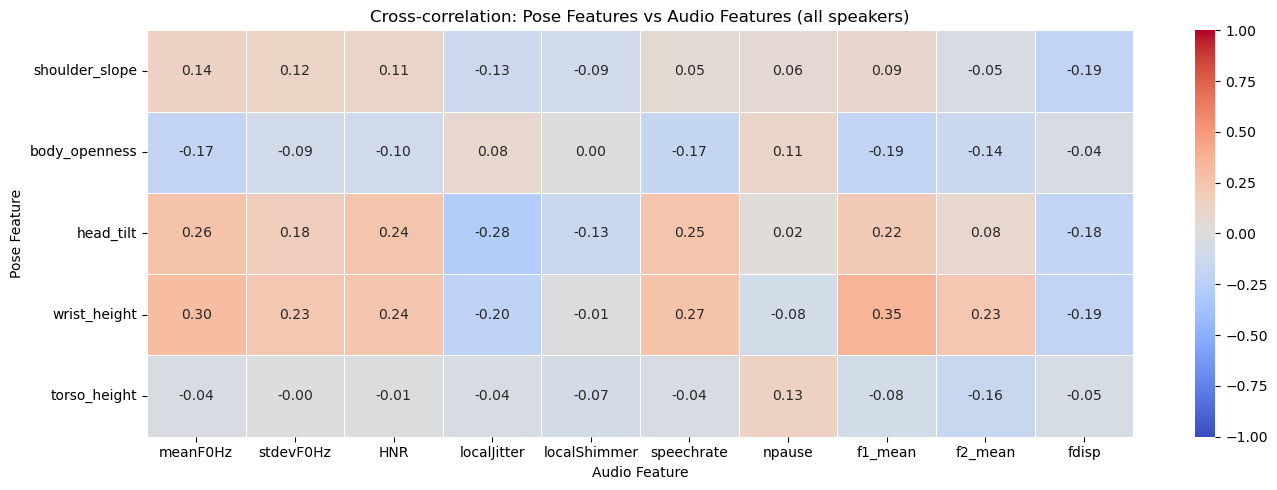

'# ── Per cluster ───────────────────────────────────────────────────────────────\nfor cluster_id in sorted(df_pose_audio[\'cluster\'].unique()):\n    df_cluster = df_pose_audio[df_pose_audio[\'cluster\'] == cluster_id]\n\n    corr_matrix = df_cluster[features_to_corr].corr(method=\'spearman\')\n    cross_corr = corr_matrix.loc[pose_feature_cols, NON_REDUNDANT]\n\n    plt.figure(figsize=(14, 5))\n    sns.heatmap(cross_corr, annot=True, fmt=".2f", cmap=\'coolwarm\',\n                vmin=-1, vmax=1, linewidths=0.5)\n    plt.title(f\'Cross-correlation: Pose Features vs Audio Features (cluster {cluster_id} — {len(df_cluster)} rows)\')\n    plt.xlabel(\'Audio Feature\')\n    plt.ylabel(\'Pose Feature\')\n    plt.tight_layout()\n    plt.show()'

In [44]:
# ── Merge cluster labels into df_master_valid ─────────────────────────────────
df_master_valid = df_master_valid.merge(
    df_merged[['frame_number', 'cluster']].drop_duplicates('frame_number'),
    on='frame_number',
    how='left'
)

df_master_valid_clustered = df_master_valid.dropna(subset=['cluster']).copy()
df_master_valid_clustered['cluster'] = df_master_valid_clustered['cluster'].astype(int)

print(f"Rows with cluster label: {len(df_master_valid_clustered)}")
print(f"Rows dropped (no audio match): {len(df_master_valid) - len(df_master_valid_clustered)}")

# ── Merge pose features with audio features ───────────────────────────────────
NON_REDUNDANT = [
    'meanF0Hz', 'stdevF0Hz', 'HNR', 'localJitter', 'localShimmer',
    'speechrate', 'npause', 'f1_mean', 'f2_mean', 'fdisp'
]
pose_feature_cols = ['shoulder_slope', 'body_openness', 'head_tilt', 'wrist_height', 'torso_height']


df_pose_audio = df_master_valid_clustered.merge(
    df_merged[['frame_number'] + NON_REDUNDANT].drop_duplicates('frame_number'),
    on='frame_number',
    how='inner'  # only keep frames that have both pose and audio
)

print(f"Rows with both pose and audio features: {len(df_pose_audio)}")
print(f"Cluster distribution:")
print(df_pose_audio['cluster'].value_counts())

# ── Global correlation ────────────────────────────────────────────────────────
features_to_corr = pose_feature_cols + NON_REDUNDANT
corr_matrix = df_pose_audio[features_to_corr].corr(method='spearman')
cross_corr = corr_matrix.loc[pose_feature_cols, NON_REDUNDANT]

plt.figure(figsize=(14, 5))
sns.heatmap(cross_corr, annot=True, fmt=".2f", cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5)
plt.title('Cross-correlation: Pose Features vs Audio Features (all speakers)')
plt.xlabel('Audio Feature')
plt.ylabel('Pose Feature')
plt.tight_layout()
plt.show()

'''# ── Per cluster ───────────────────────────────────────────────────────────────
for cluster_id in sorted(df_pose_audio['cluster'].unique()):
    df_cluster = df_pose_audio[df_pose_audio['cluster'] == cluster_id]
    
    corr_matrix = df_cluster[features_to_corr].corr(method='spearman')
    cross_corr = corr_matrix.loc[pose_feature_cols, NON_REDUNDANT]
    
    plt.figure(figsize=(14, 5))
    sns.heatmap(cross_corr, annot=True, fmt=".2f", cmap='coolwarm',
                vmin=-1, vmax=1, linewidths=0.5)
    plt.title(f'Cross-correlation: Pose Features vs Audio Features (cluster {cluster_id} — {len(df_cluster)} rows)')
    plt.xlabel('Audio Feature')
    plt.ylabel('Pose Feature')
    plt.tight_layout()
    plt.show()'''

modality correlations in debate videos are dominated by who is speaking, not by genuine cross-modal relationships?

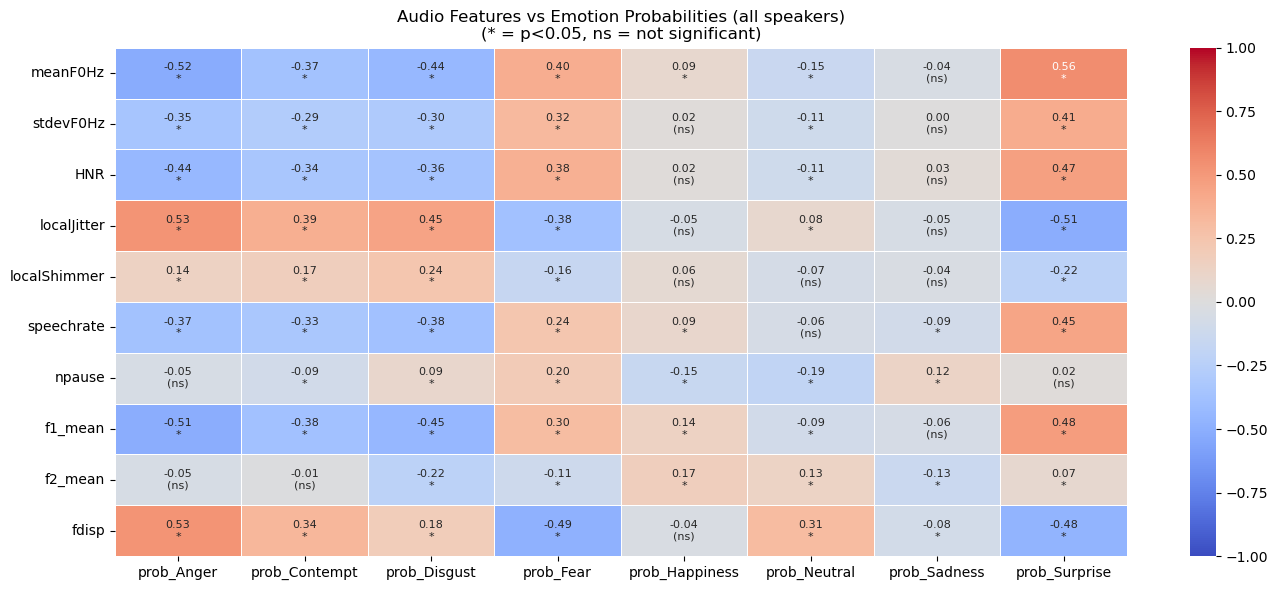

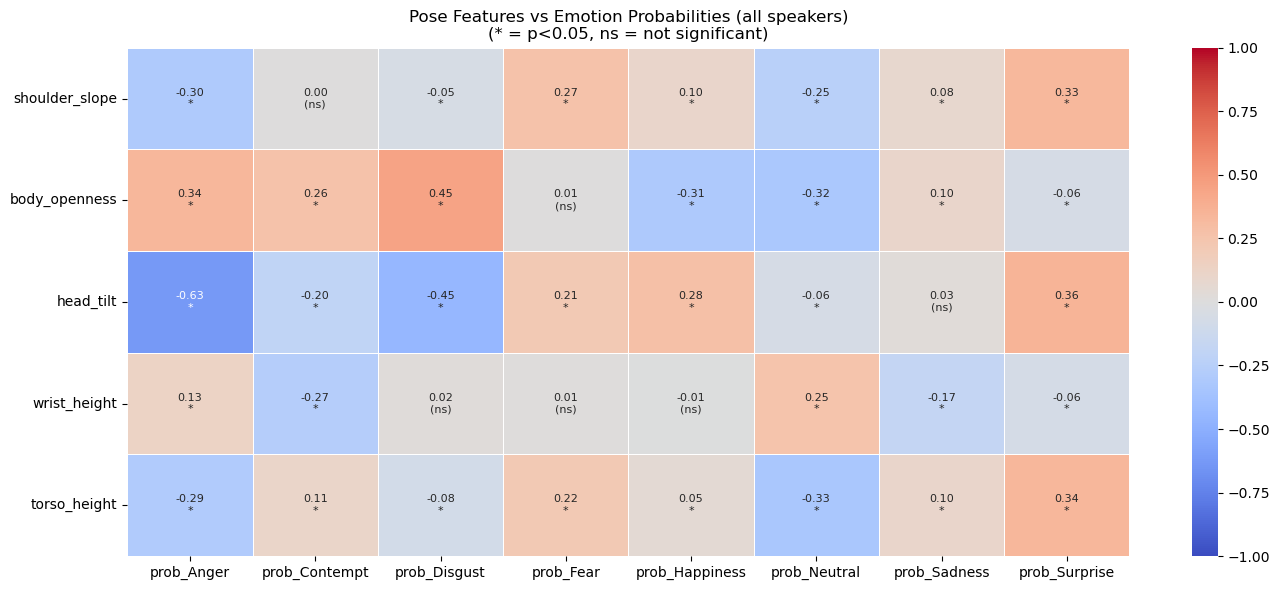

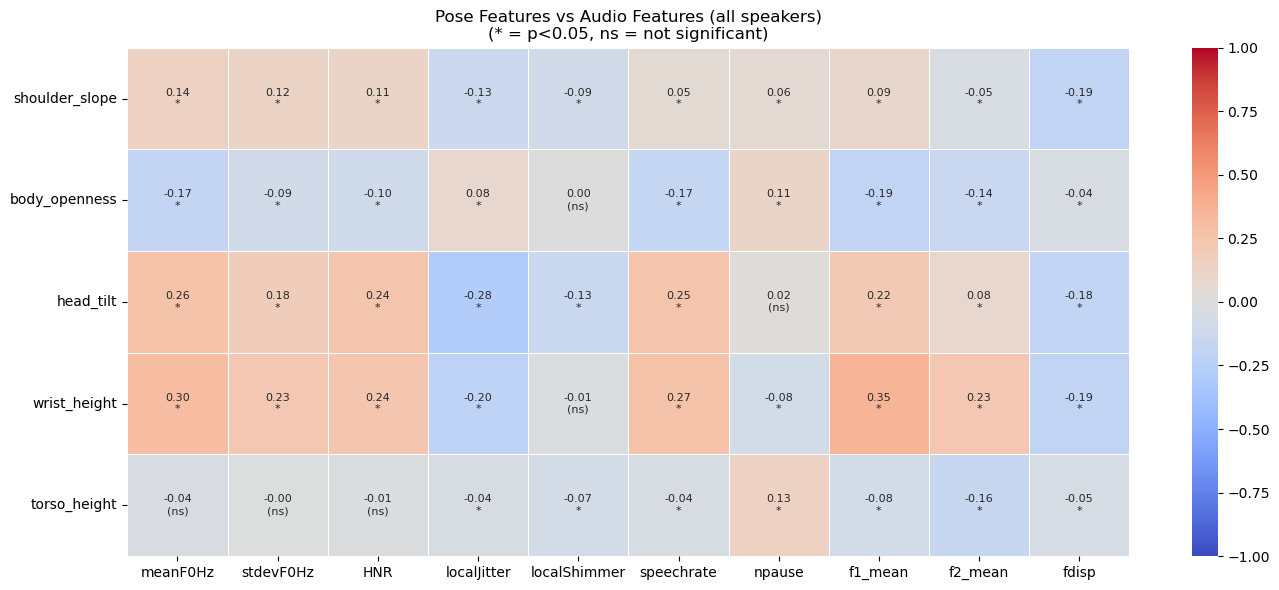

In [45]:
from scipy.stats import spearmanr

def compute_corr_with_pvalues(df, features_rows, features_cols):
    """
    Computes spearman correlation and p-values between two sets of features.
    Returns two dataframes: correlations and p-values.
    """
    corr_data = pd.DataFrame(index=features_rows, columns=features_cols, dtype=float)
    pval_data = pd.DataFrame(index=features_rows, columns=features_cols, dtype=float)
    
    for feat_row in features_rows:
        for feat_col in features_cols:
            # drop NaN pairs
            valid = df[[feat_row, feat_col]].dropna()
            rho, pval = spearmanr(valid[feat_row], valid[feat_col])
            corr_data.loc[feat_row, feat_col] = rho
            pval_data.loc[feat_row, feat_col] = pval
    
    return corr_data, pval_data


def plot_corr_with_significance(corr_data, pval_data, title, significance=0.05):
    """
    Plots a heatmap with correlation values.
    Cells with p-value > significance threshold are marked with 'x' (not significant).
    """
    # Build annotation: show correlation value + mark non-significant with *
    annot = pd.DataFrame(index=corr_data.index, columns=corr_data.columns)
    for r in corr_data.index:
        for c in corr_data.columns:
            rho = corr_data.loc[r, c]
            pval = pval_data.loc[r, c]
            if pval > significance:
                annot.loc[r, c] = f'{rho:.2f}\n(ns)'  # not significant
            else:
                annot.loc[r, c] = f'{rho:.2f}\n*'     # significant
    
    plt.figure(figsize=(14, 6))
    sns.heatmap(
        corr_data.astype(float),
        annot=annot,
        fmt='',
        cmap='coolwarm',
        vmin=-1, vmax=1,
        linewidths=0.5,
        annot_kws={'size': 8}
    )
    plt.title(f'{title}\n(* = p<{significance}, ns = not significant)')
    plt.tight_layout()
    plt.show()


# ── 1. Audio vs Emotion — global ──────────────────────────────────────────────
emotion_cols = [c for c in df_one_face.columns if c.startswith('prob_')]

corr_data, pval_data = compute_corr_with_pvalues(df_one_face, NON_REDUNDANT, emotion_cols)
plot_corr_with_significance(corr_data, pval_data, 
                            'Audio Features vs Emotion Probabilities (all speakers)')

# ── 2. Pose vs Emotion — global ───────────────────────────────────────────────
pose_feature_cols = ['shoulder_slope', 'body_openness', 'head_tilt', 'wrist_height', 'torso_height']
emotion_cols_master = [c for c in df_master_valid.columns if c.startswith('prob_')]

corr_data, pval_data = compute_corr_with_pvalues(df_master_valid, pose_feature_cols, emotion_cols_master)
plot_corr_with_significance(corr_data, pval_data,
                            'Pose Features vs Emotion Probabilities (all speakers)')

# ── 3. Pose vs Audio — global ─────────────────────────────────────────────────
corr_data, pval_data = compute_corr_with_pvalues(df_pose_audio, pose_feature_cols, NON_REDUNDANT)
plot_corr_with_significance(corr_data, pval_data,
                            'Pose Features vs Audio Features (all speakers)')

## Is one modality enough to represent the videos?

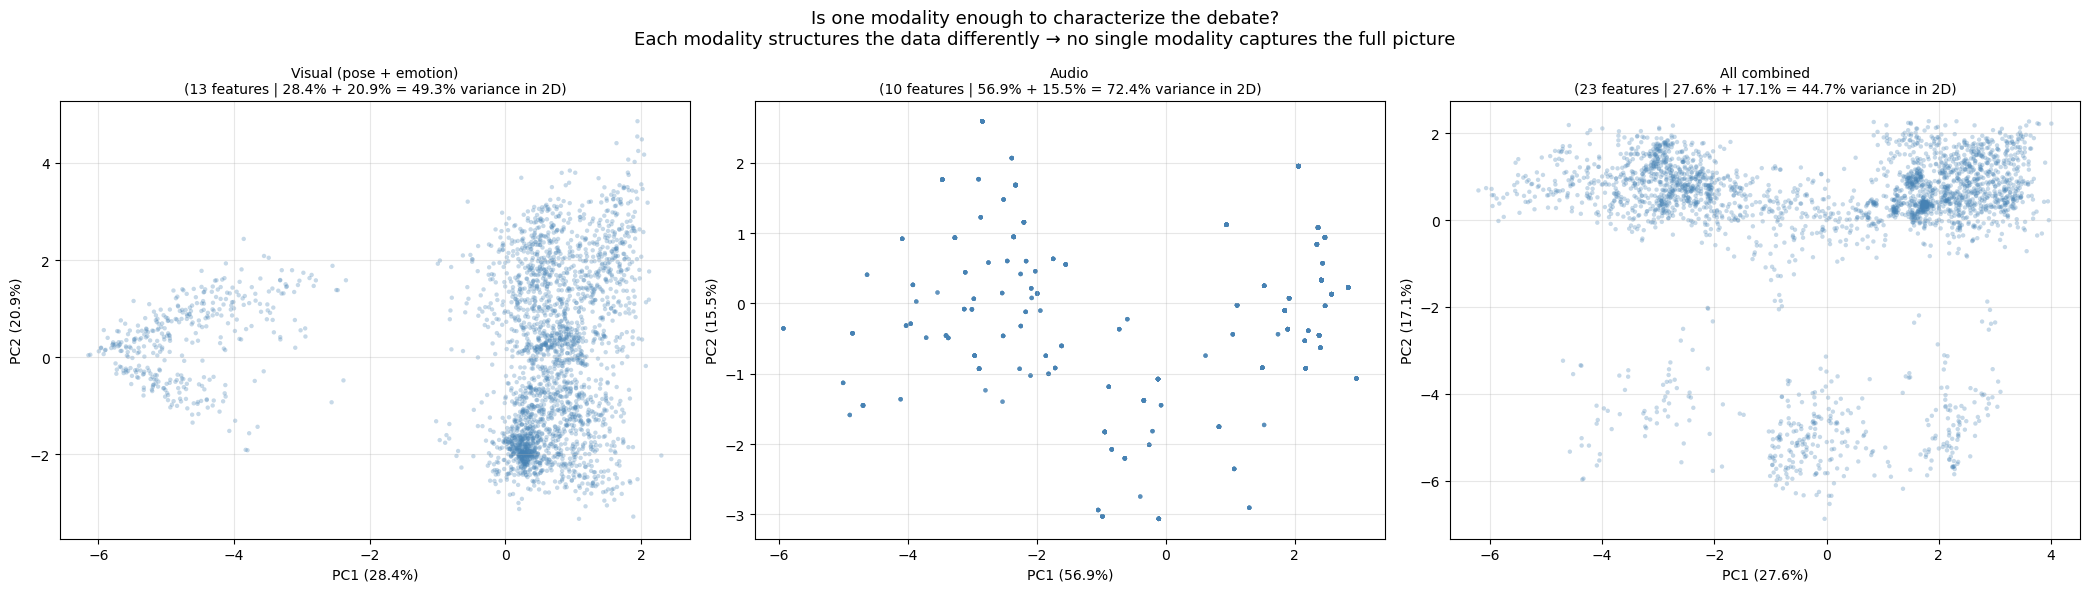

Dimensionality analysis per modality:
Modality                         Features  2D variance   90% variance needs
---------------------------------------------------------------------------
Visual (pose + emotion)                13        49.3%                  8 PCs
Audio                                  10        72.4%                  5 PCs
All combined                           23        44.7%                 12 PCs

Correlation between Visual and Audio PCA spaces:
  PC1: rho=-0.164  p=0.0000
  PC2: rho=-0.033  p=0.0841

→ Low correlation between modality spaces confirms they capture different information
→ No single modality is sufficient to characterize the debate


In [47]:
# ── Feature sets per modality ─────────────────────────────────────────────────
visual_features = pose_feature_cols + [c for c in df_pose_audio.columns if c.startswith('prob_')]
audio_features = NON_REDUNDANT

# Use df_pose_audio as base — already has both modalities, drop any NaNs
df_modality = df_pose_audio[visual_features + audio_features + ['cluster']].dropna()


# ── PCA per modality — no cluster labels, just structure ─────────────────────
modalities = {
    'Visual (pose + emotion)': visual_features,
    'Audio':                   audio_features,
    'All combined':            visual_features + audio_features
}

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle(
    'Is one modality enough to characterize the debate?\n'
    'Each modality structures the data differently → no single modality captures the full picture',
    fontsize=13
)

pca_results = {}  # store for later comparison

for ax, (modality_name, features) in zip(axes, modalities.items()):
    X = df_modality[features].values
    X_scaled = StandardScaler().fit_transform(X)
    
    pca = PCA(n_components=2, random_state=42)
    X_2d = pca.fit_transform(X_scaled)
    var1 = pca.explained_variance_ratio_[0] * 100
    var2 = pca.explained_variance_ratio_[1] * 100
    explained_total = var1 + var2
    
    pca_results[modality_name] = {
        'X_2d': X_2d,
        'var1': var1,
        'var2': var2,
        'explained_total': explained_total,
        'n_components_90': np.argmax(np.cumsum(PCA().fit(X_scaled).explained_variance_ratio_) >= 0.90) + 1
    }
    
    # color by density instead of clusters
    ax.scatter(
        X_2d[:, 0], X_2d[:, 1],
        c='steelblue', alpha=0.3, s=10, edgecolors='none'
    )
    
    ax.set_title(
        f'{modality_name}\n'
        f'({len(features)} features | {var1:.1f}% + {var2:.1f}% = {explained_total:.1f}% variance in 2D)',
        fontsize=10
    )
    ax.set_xlabel(f'PC1 ({var1:.1f}%)')
    ax.set_ylabel(f'PC2 ({var2:.1f}%)')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ── How many components needed to explain 90% variance per modality? ──────────
print('Dimensionality analysis per modality:')
print(f'{"Modality":<30} {"Features":>10} {"2D variance":>12} {"90% variance needs":>20}')
print('-' * 75)
for modality_name, results in pca_results.items():
    n_features = len(modalities[modality_name])
    print(
        f'{modality_name:<30} '
        f'{n_features:>10} '
        f'{results["explained_total"]:>11.1f}% '
        f'{results["n_components_90"]:>18} PCs'
    )

# ── Correlation between PCA spaces ───────────────────────────────────────────
# If visual and audio PCA spaces were similar, their PC1s would correlate strongly
# Low correlation = they capture different structure
from scipy.stats import spearmanr

visual_pc1 = pca_results['Visual (pose + emotion)']['X_2d'][:, 0]
audio_pc1  = pca_results['Audio']['X_2d'][:, 0]
visual_pc2 = pca_results['Visual (pose + emotion)']['X_2d'][:, 1]
audio_pc2  = pca_results['Audio']['X_2d'][:, 1]

rho_pc1, p_pc1 = spearmanr(visual_pc1, audio_pc1)
rho_pc2, p_pc2 = spearmanr(visual_pc2, audio_pc2)

print(f'\nCorrelation between Visual and Audio PCA spaces:')
print(f'  PC1: rho={rho_pc1:.3f}  p={p_pc1:.4f}')
print(f'  PC2: rho={rho_pc2:.3f}  p={p_pc2:.4f}')
print()
if abs(rho_pc1) < 0.3 and abs(rho_pc2) < 0.3:
    print('→ Low correlation between modality spaces confirms they capture different information')
    print('→ No single modality is sufficient to characterize the debate')
else:
    print('→ Moderate correlation between modality spaces — partial overlap in information')

Conclusion: the two modality spaces are essentially uncorrelated. 
They are capturing completely different aspects of the debate